In [1]:
# from Engine_config import Engine
from Engine_UE2_config import Engine
import json
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import json
from pathlib import Path

engine = Engine()

2026-01-09 16:29:02.409907: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-09 16:29:02.461549: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 16:29:03.789074: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


['nyu_tandon']
bbox_lat: [40.69012764197041, 40.699120858029595]
bbox_long: [-73.99156687083165, -73.97970552916836]
address: 5 MetroTech Center, Brooklyn, NY 11201
descr: NYU Tandon campus
2026-01-09 16:29:07 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
no-name-1      itu_marble
ground         itu_concrete


############################################################
route:  80 , sub:  0
R speed:  2


  0%|          | 0/1200 [00:00<?, ?it/s]

100%|██████████| 1200/1200 [03:37<00:00,  5.51it/s]


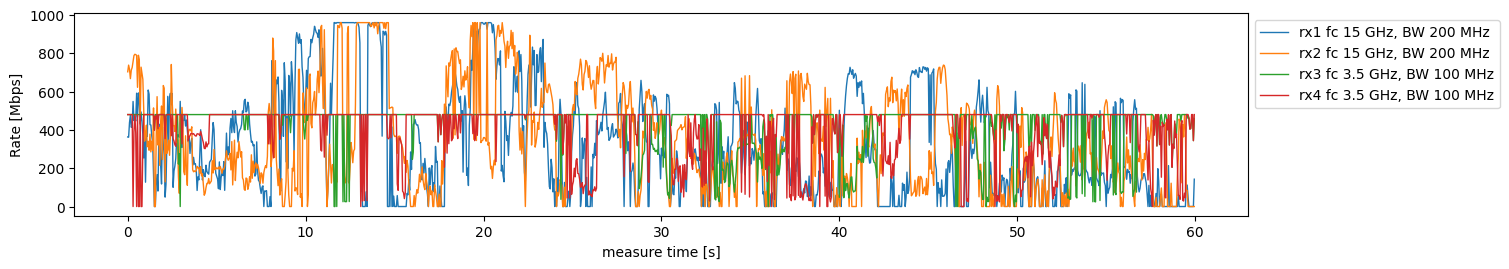

############################################################
route:  80 , sub:  1
R speed:  2


100%|██████████| 1200/1200 [03:24<00:00,  5.88it/s]


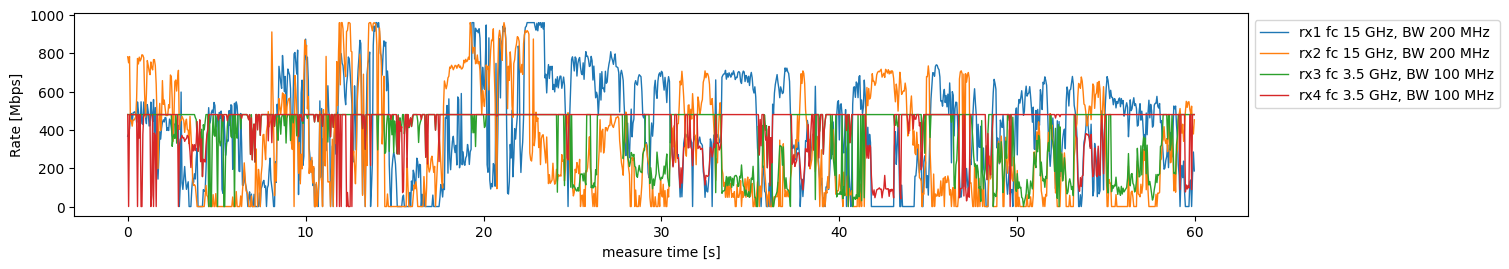

############################################################
route:  80 , sub:  2
R speed:  2


100%|██████████| 1200/1200 [03:19<00:00,  6.00it/s]


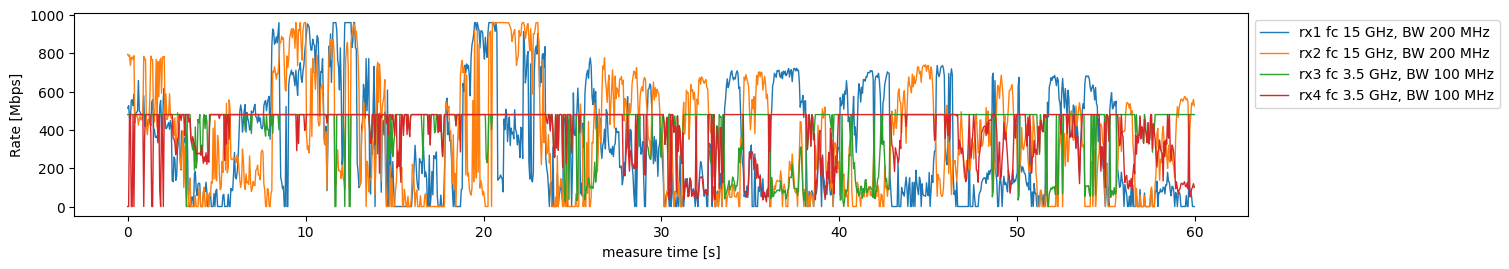

############################################################
route:  80 , sub:  3
R speed:  2


100%|██████████| 1200/1200 [03:17<00:00,  6.08it/s]


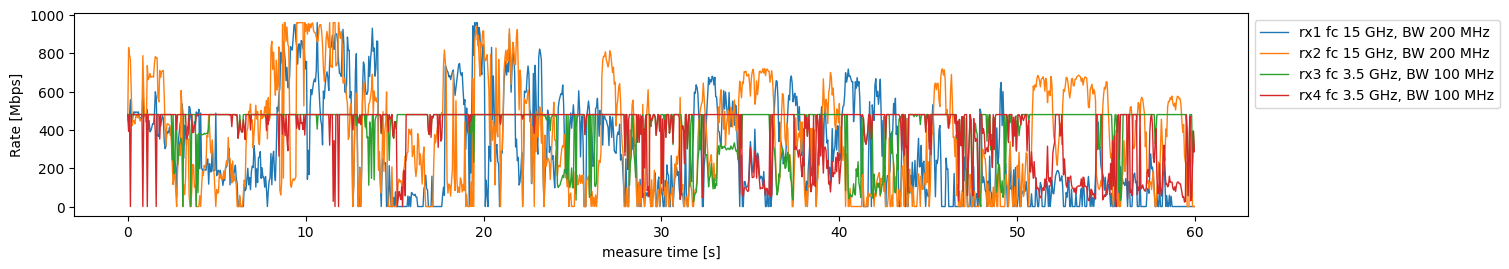

############################################################
route:  80 , sub:  4
R speed:  2


100%|██████████| 1200/1200 [03:16<00:00,  6.10it/s]


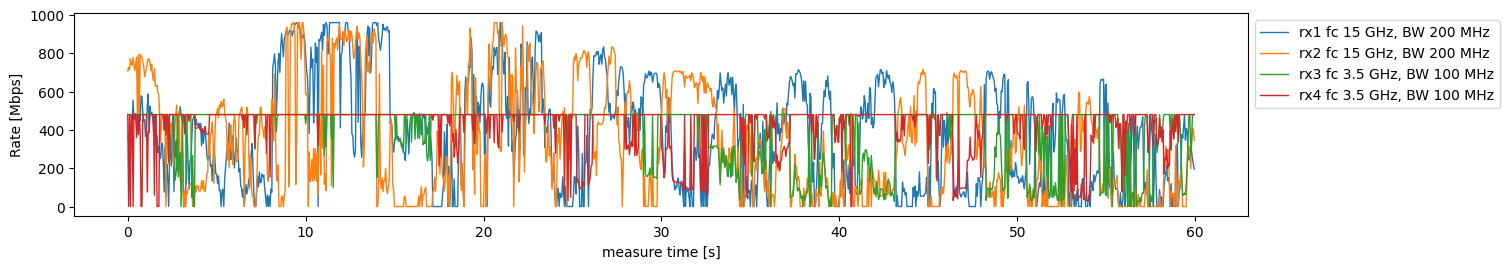

############################################################
route:  80 , sub:  5
R speed:  2


100%|██████████| 1200/1200 [03:16<00:00,  6.11it/s]


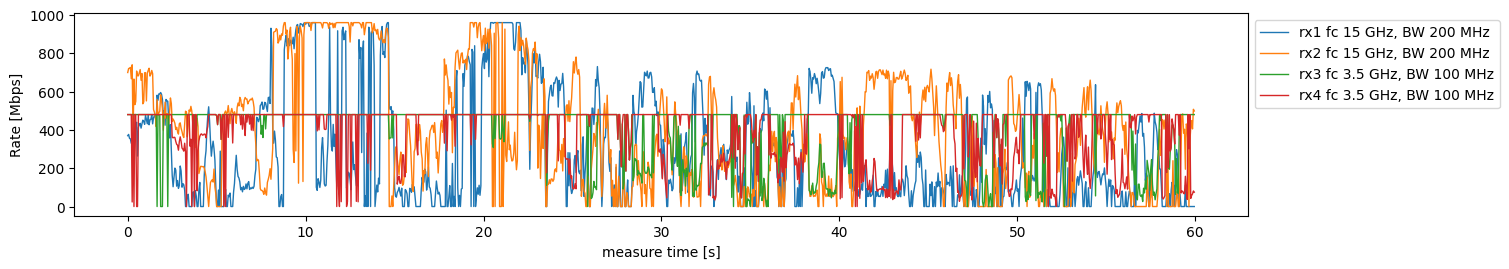

############################################################
route:  80 , sub:  6
R speed:  2


100%|██████████| 1200/1200 [03:14<00:00,  6.18it/s]


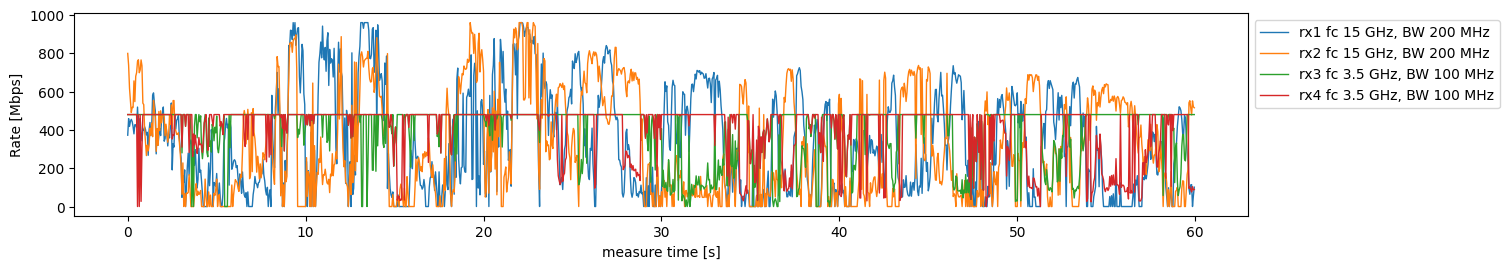

############################################################
route:  80 , sub:  7
R speed:  2


100%|██████████| 1200/1200 [03:13<00:00,  6.19it/s]


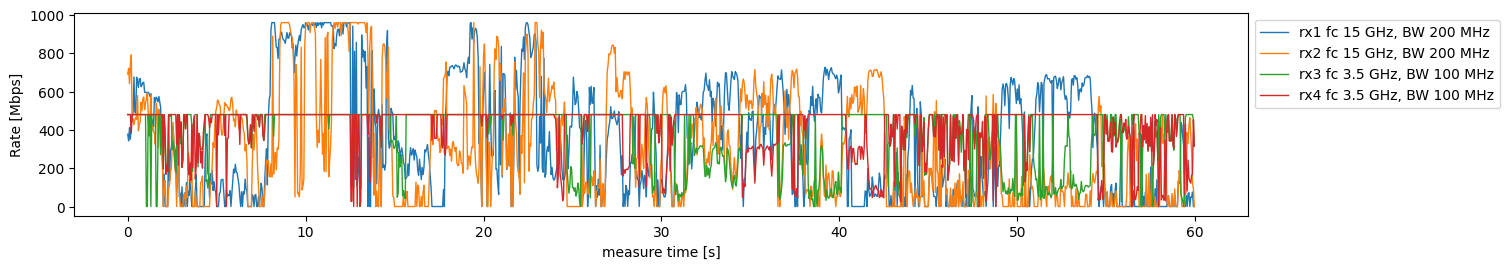

############################################################
route:  80 , sub:  8
R speed:  2


100%|██████████| 1200/1200 [03:13<00:00,  6.19it/s]


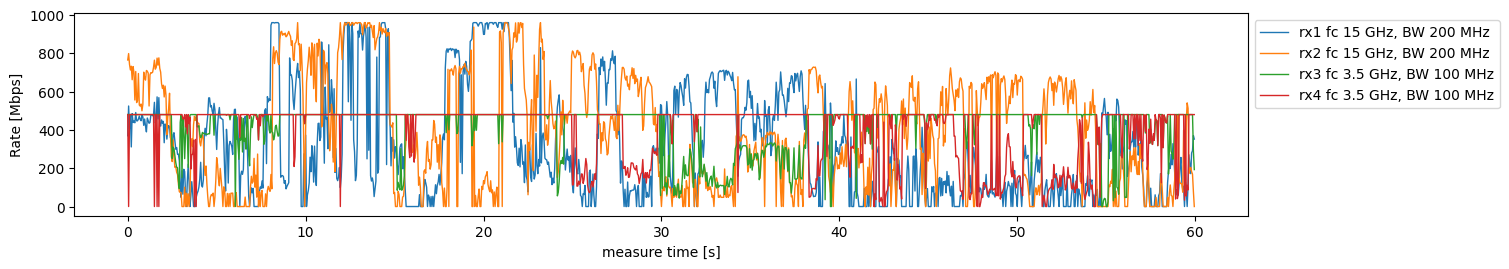

############################################################
route:  80 , sub:  9
R speed:  2


100%|██████████| 1200/1200 [03:14<00:00,  6.17it/s]


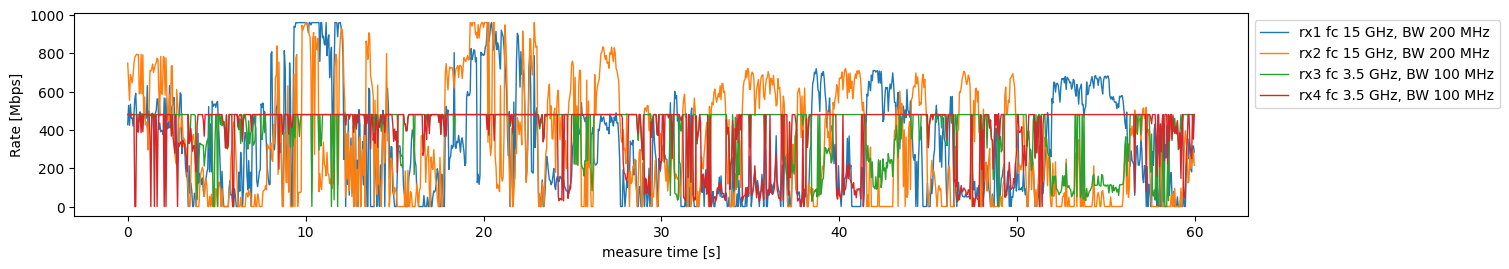

In [2]:
folder_path = '..//dataset_multi_5mps/dataset_raw/'

folder = Path(folder_path)
folder.mkdir(exist_ok=True, parents=True)

for path_idx in range(80,81):

    nloop = 10

    for idx in range(nloop):
        
        print("############################################################")
        print("route: ", path_idx, ", sub: ", idx)
        print("R speed: ", engine.R_speed)
        rate_total, hp_total, yaw_total, pitch_total, snr_total = engine.run_from_file('..//dataset_multi_5mps/route/region_1_' + str(path_idx) + '_60s_10mps.json')

        #file_rate = '51_region_1_2_' + str(idx) +  '_60s_rate.json'

        file_prefix = folder_path + '51_region_1_' + str(path_idx) + '_' + str(idx) +  '_60s_R2'

        with open(file_prefix + '_rate.json', 'w') as f:
            json.dump(rate_total, f)
            
        with open(file_prefix + '_hp.json', 'w') as f:
            json.dump(hp_total, f)

        with open(file_prefix + '_snr.json', 'w') as f:
            json.dump(snr_total, f)

        N_measure = len(rate_total)

        measure_index = range(N_measure)
        messuare_period = 0.05
        rate_total = np.array(rate_total)

        plt.figure(figsize=(15, 2.6))

        plt.plot(np.array(measure_index) * messuare_period, rate_total[:,0], label=f"rx1 fc 15 GHz, BW 200 MHz", linewidth=1)
        plt.plot(np.array(measure_index) * messuare_period, rate_total[:,1], label=f"rx2 fc 15 GHz, BW 200 MHz", linewidth=1)
        plt.plot(np.array(measure_index) * messuare_period, rate_total[:,2], label=f"rx3 fc 3.5 GHz, BW 100 MHz", linewidth=1)
        plt.plot(np.array(measure_index) * messuare_period, rate_total[:,3], label=f"rx4 fc 3.5 GHz, BW 100 MHz", linewidth=1)
        # plt.plot(np.array(measure_index) * messuare_period / 60, rate_35, label=f"fc 3.5 GHz, BW 100 MHz")
        # plt.legend(loc = "lower left")
        plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.xlabel("measure time [s]")
        plt.ylabel("Rate [Mbps]")
        # plt.xlim(10,11)
        plt.show()


        # # plot rate
        # plt.figure(figsize=(12, 2.6))
        # plt.plot(np.array(measure_index) * messuare_period / 60, yaw_total, label=f"yaw angles", linewidth=1)
        # plt.plot(np.array(measure_index) * messuare_period / 60, pitch_total, label=f"pitch angles", linewidth=1)
        # plt.legend()
        # plt.xlabel("measure time [min]]")
        # plt.ylabel("Yaw angle")
        # # plt.ylim(-75,-60)
        # plt.show()